In [48]:
import pandas as pd
df=pd.read_csv("Titanic.csv")
df.head()

,PassengerId,Survived,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Cabin,Embarked
0,1,0,3,"Braund, Mr. Owen Harris",male,22.0,1,0,A/5 21171,7.2500,NaN,S
1,2,1,1,"Cumings, Mrs. John Bradley (Florence Briggs Th...",female,38.0,1,0,PC 17599,71.2833,C85,C
2,3,1,3,"Heikkinen, Miss. Laina",female,26.0,0,0,STON/O2. 3101282,7.9250,NaN,S
3,4,1,1,"Futrelle, Mrs. Jacques Heath (Lily May Peel)",female,35.0,1,0,113803,53.1000,C123,S
4,5,0,3,"Allen, Mr. William Henry",male,35.0,0,0,373450,8.0500,NaN,S


In [49]:
print(df.shape)

(891, 12)


In [50]:
print(df.info())

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 891 entries, 0 to 890
Data columns (total 12 columns):
 #   Column       Non-Null Count  Dtype  
---  ------       --------------  -----  
 0   PassengerId  891 non-null    int64  
 1   Survived     891 non-null    int64  
 2   Pclass       891 non-null    int64  
 3   Name         891 non-null    object 
 4   Sex          891 non-null    object 
 5   Age          714 non-null    float64
 6   SibSp        891 non-null    int64  
 7   Parch        891 non-null    int64  
 8   Ticket       891 non-null    object 
 9   Fare         891 non-null    float64
 10  Cabin        204 non-null    object 
 11  Embarked     889 non-null    object 
dtypes: float64(2), int64(5), object(5)
memory usage: 83.7+ KB
None


In [51]:
print(df.isnull().sum())

PassengerId      0
Survived         0
Pclass           0
Name             0
Sex              0
Age            177
SibSp            0
Parch            0
Ticket           0
Fare             0
Cabin          687
Embarked         2
dtype: int64


In [52]:
Q1=df["Age"].quantile(0.25)
Q3=df["Age"].quantile(0.75)
iqr=Q3-Q1
lower_bound=Q1-1.5*iqr
upper_bound=Q3+1.5*iqr
outliers=data[(df["Age"]<lower_bound) | (df["Age"]>upper_bound)]
print("lower bound : ",lower_bound)
print("upper bound : ",upper_bound)
print("Outilers Count : ",outliers)

lower bound :  -6.6875
upper bound :  64.8125
Outilers Count :       PassengerId  Survived  Pclass                                  Name  \
33            34         0       2                 Wheadon, Mr. Edward H   
54            55         0       1        Ostby, Mr. Engelhart Cornelius   
96            97         0       1             Goldschmidt, Mr. George B   
116          117         0       3                  Connors, Mr. Patrick   
280          281         0       3                      Duane, Mr. Frank   
456          457         0       1             Millet, Mr. Francis Davis   
493          494         0       1               Artagaveytia, Mr. Ramon   
630          631         1       1  Barkworth, Mr. Algernon Henry Wilson   
672          673         0       2           Mitchell, Mr. Henry Michael   
745          746         0       1          Crosby, Capt. Edward Gifford   
851          852         0       3                   Svensson, Mr. Johan   

      Sex   Age  SibSp 

In [53]:
df["Age"]=df["Age"].clip(lower=lower_bound,upper=upper_bound)
print(df["Age"].max())
print(df["Age"].min())

64.8125
0.42


In [54]:
df[df['Age'] == df['Age'].min()]

,PassengerId,Survived,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Cabin,Embarked
803,804,1,3,"Thomas, Master. Assad Alexander",male,0.42,0,1,2625,8.5167,NaN,C


In [55]:
df['Age'] = df['Age'].fillna(df['Age'].median())
print(df['Age'].isnull().sum())

0


In [56]:
df.isnull().sum()

PassengerId      0
Survived         0
Pclass           0
Name             0
Sex              0
Age              0
SibSp            0
Parch            0
Ticket           0
Fare             0
Cabin          687
Embarked         2
dtype: int64

In [57]:
df['Embarked'] = df['Embarked'].fillna(df['Embarked'].mode()[0])
df = df.drop(columns=['Cabin'])
df = df.drop_duplicates()

In [58]:
print(df.isnull().sum())
print("Duplicates:", df.duplicated().sum())

PassengerId    0
Survived       0
Pclass         0
Name           0
Sex            0
Age            0
SibSp          0
Parch          0
Ticket         0
Fare           0
Embarked       0
dtype: int64
Duplicates: 0


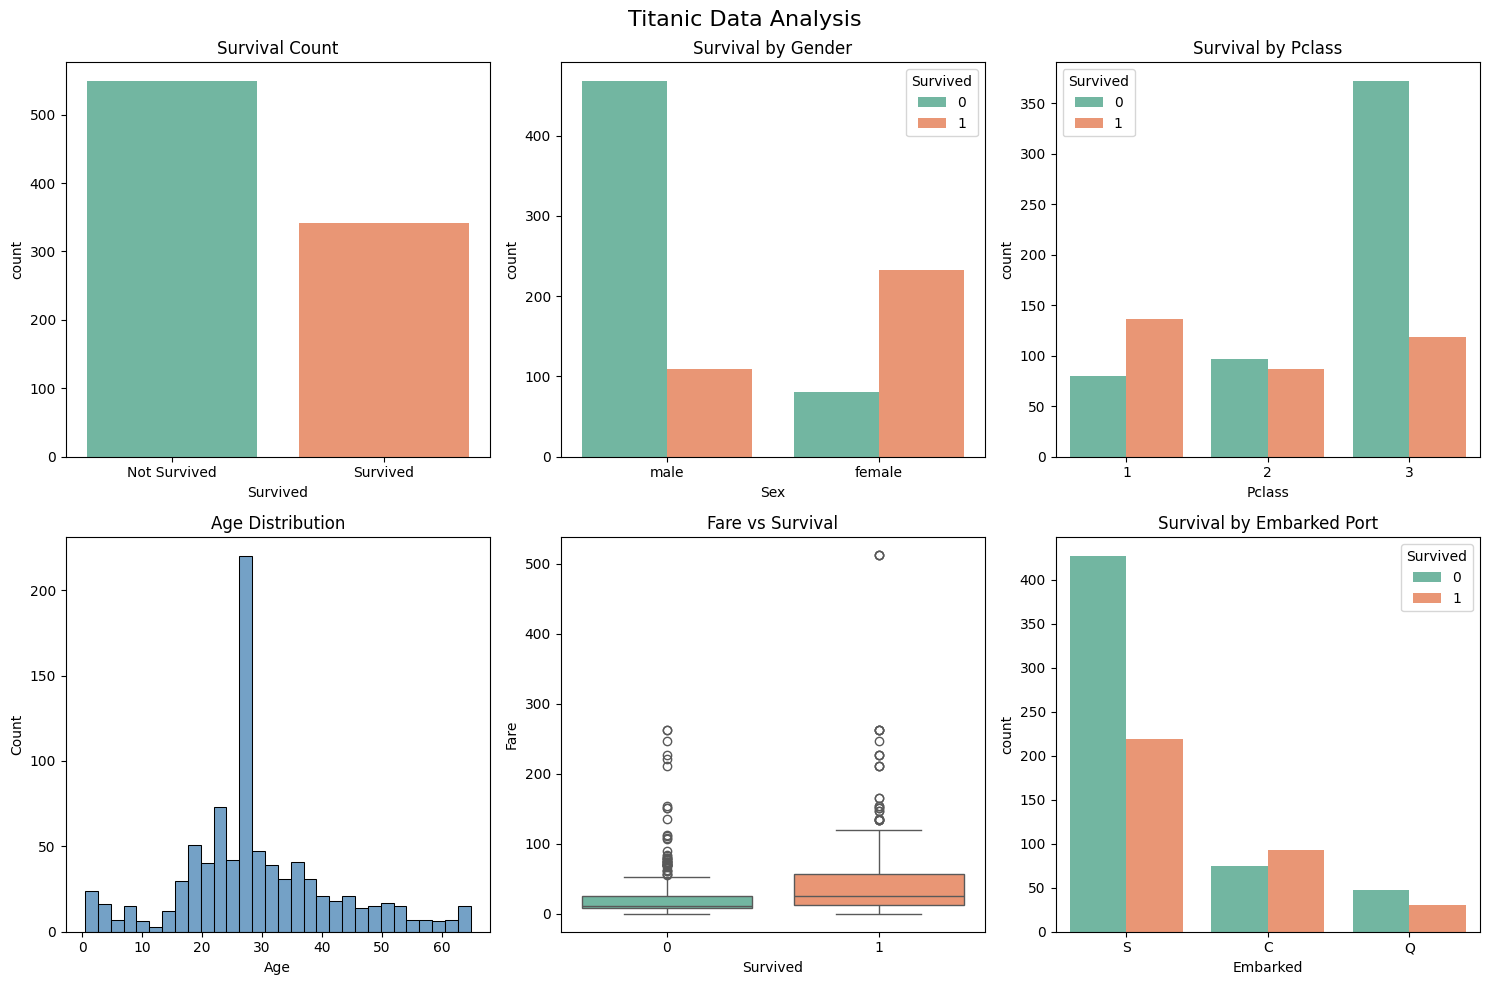

In [59]:
import matplotlib.pyplot as plt
import seaborn as sns

fig, axes = plt.subplots(2, 3, figsize=(15, 10))
fig.suptitle('Titanic Data Analysis', fontsize=16)

# 1. Survival Count
sns.countplot(x='Survived', hue='Survived', data=df, ax=axes[0,0], palette='Set2', legend=False)
axes[0,0].set_title('Survival Count')
axes[0,0].set_xticks([0, 1])
axes[0,0].set_xticklabels(['Not Survived', 'Survived'])

# 2. Survival by Gender
sns.countplot(x='Sex', hue='Survived', data=df, ax=axes[0,1], palette='Set2')
axes[0,1].set_title('Survival by Gender')

# 3. Survival by Pclass
sns.countplot(x='Pclass', hue='Survived', data=df, ax=axes[0,2], palette='Set2')
axes[0,2].set_title('Survival by Pclass')

# 4. Age Distribution
sns.histplot(df['Age'], bins=30, ax=axes[1,0], color='steelblue')
axes[1,0].set_title('Age Distribution')

# 5. Fare vs Survival
sns.boxplot(x='Survived', y='Fare', hue='Survived', data=df, ax=axes[1,1], palette='Set2', legend=False)
axes[1,1].set_title('Fare vs Survival')

# 6. Embarked Count
sns.countplot(x='Embarked', hue='Survived', data=df, ax=axes[1,2], palette='Set2')
axes[1,2].set_title('Survival by Embarked Port')

plt.tight_layout()
plt.savefig('titanic_analysis.png', dpi=150)
plt.show()